In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
import fasttext

<class 'ModuleNotFoundError'>: No module named 'fasttext'

In [ ]:
np.__version__

In [2]:
with open("/lustre/fswork/projects/rech/knb/ukq43aj/Datasets/Eval-Math-FR/eval.json", "r") as f:
    results = json.load(f)
datasets = list(list(results.values())[0]["accuracies"].keys())
n_models = len(results)

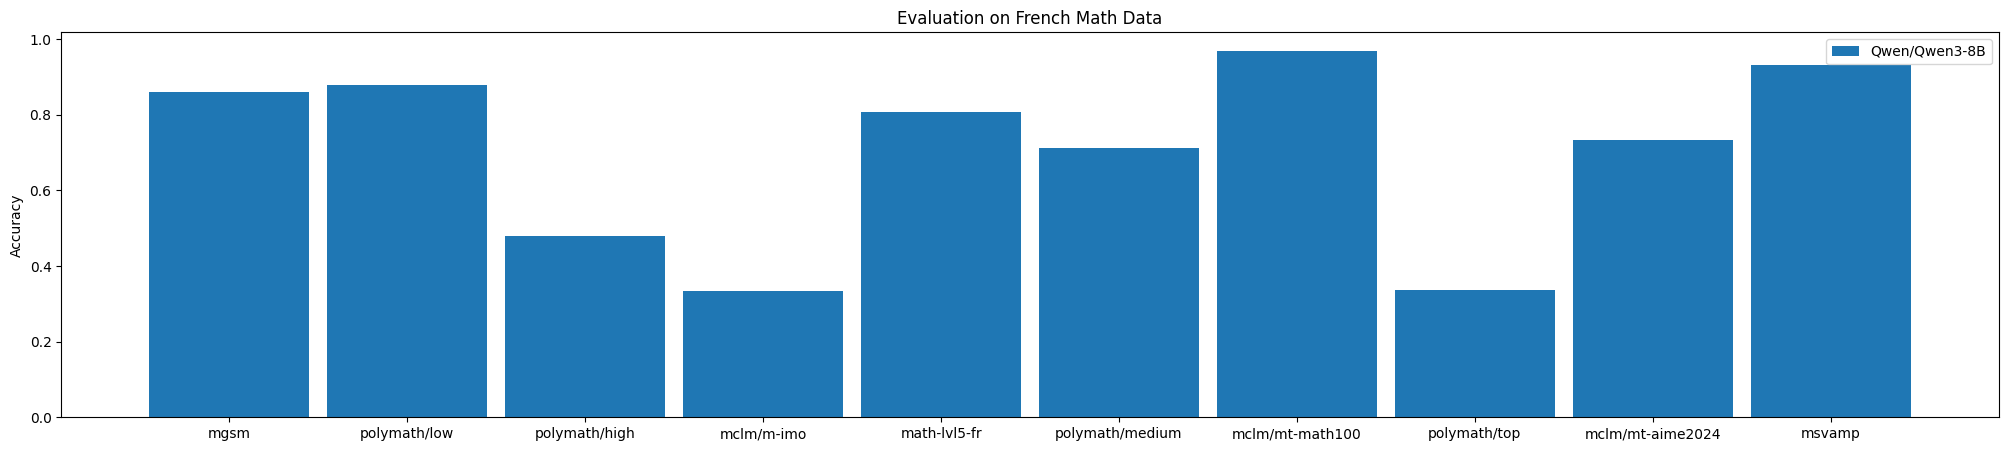

In [3]:
fig, ax = plt.subplots(figsize=(25,5))
for i, (model, result) in enumerate(results.items()):
    ax.bar(np.arange(len(datasets)) + (i-(0.5*(n_models-1)))/n_models, list(result["accuracies"].values()), width=0.9/n_models, label=model)

ax.set_xticks(np.arange(len(datasets)))
ax.set_xticklabels(datasets)
ax.set_ylabel("Accuracy")
ax.set_title("Evaluation on French Math Data")
ax.legend()
plt.savefig("accuracy.png")
plt.show()

/linkhome/rech/genlor01/ukq43aj/.cache/huggingface/hub/models--facebook--fasttext-language-identification/snapshots/3af127d4124fc58b75666f3594bb5143b9757e78/model.bin
Okay, let's see. The problem says that Jimmy has $2 more than twice the amount of money Ethel has. And Ethel has $8. So I need to figure out how much money Jimmy has.  First, let me make sure I understand the problem correctly. It's in French, but I think I got the translation right. "Jimmy a 2 $ de plus que le double de l'argent d'Ethel." So, translating that, it's "Jimmy has $2 more than twice the amount of money Ethel has." And Ethel has $8. So, we need to calculate Jimmy's amount based on that.  Alright, so let's break it down. Let me recall how to translate this into a mathematical expression. The key here is to identify the operations involved. The phrase "twice the amount of money Ethel has" would be 2 multiplied by Ethel's amount. Then, adding $2 to that result gives Jimmy's total.  So, if Ethel has $8, then twice

ValueError: Unable to avoid copy while creating an array as requested.
If using `np.array(obj, copy=False)` replace it with `np.asarray(obj)` to allow a copy when needed (no behavior change in NumPy 1.x).
For more details, see https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword.

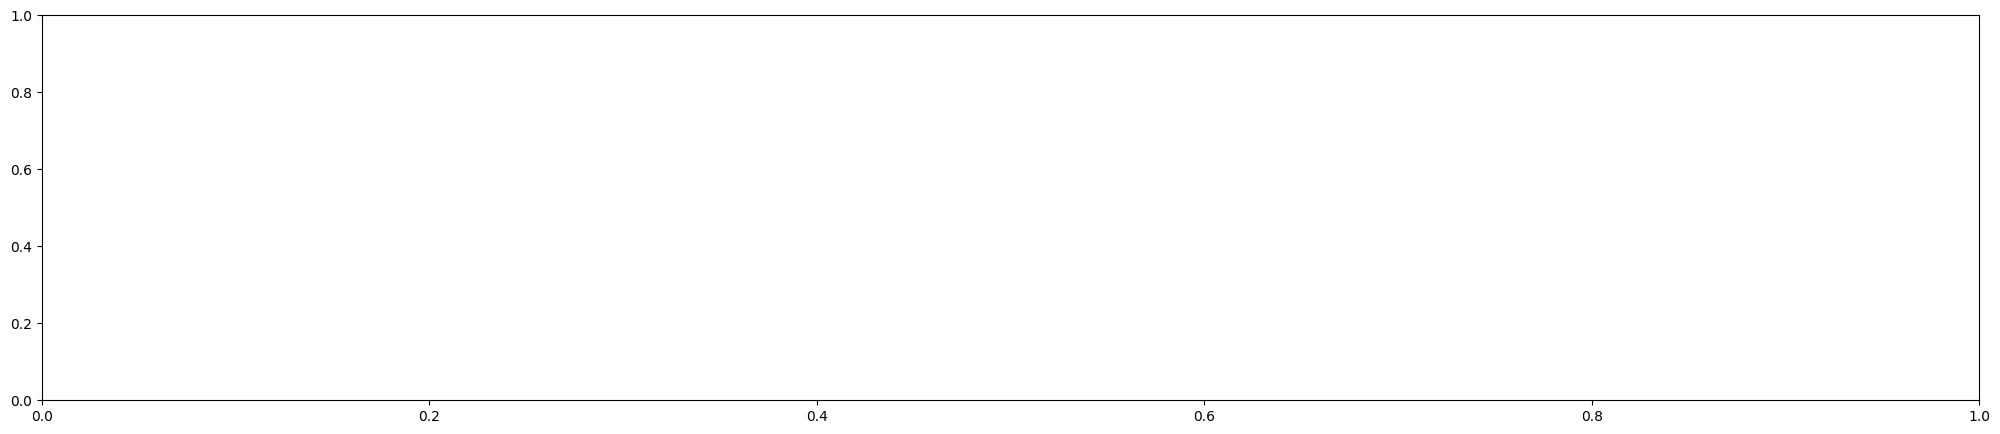

In [50]:
model_path = hf_hub_download(repo_id="facebook/fasttext-language-identification", filename="model.bin")
print(model_path)
classifier = fasttext.load_model(model_path)

fig, ax = plt.subplots(figsize=(25,5))
for i, (model, result) in enumerate(results.items()):
    languages = {}
    top_languages = {}
    for dataset in datasets:
        languages_dataset = {}
        for sample in result["samples"][dataset]:
            lang_pred = classifier.predict(sample["generation"].replace("\n", " "), k=3)
            for lang, prob in zip(lang_pred[0], lang_pred[1]):
                lang = lang.split("__label__")[1]
                if lang in languages_dataset:
                    languages_dataset[lang] += prob
                else:
                    languages_dataset[lang] = prob
                if lang in languages:
                    languages[lang] += prob
                else:
                    languages[lang] = prob
        for lang in languages_dataset.keys():
            languages_dataset[lang] = languages_dataset[lang] / len(result["samples"][dataset])
        print(dataset, ":", languages_dataset)
    for lang in languages.keys():
        languages[lang] = languages[lang] / sum([len(result["samples"][dataset]) for dataset in datasets])
        if languages[lang] > 0.005:
            top_languages[lang] = languages[lang]

    ax.bar(np.arange(len(top_languages)) + (i-(0.5*(n_models-1)))/n_models, list(top_languages.values()), width=0.9/n_models, label=model)

ax.set_xticks(np.arange(len(top_languages)))
ax.set_xticklabels(top_languages)
ax.set_ylabel("Percentage")
ax.set_title("Solution language")
ax.legend()
plt.show()

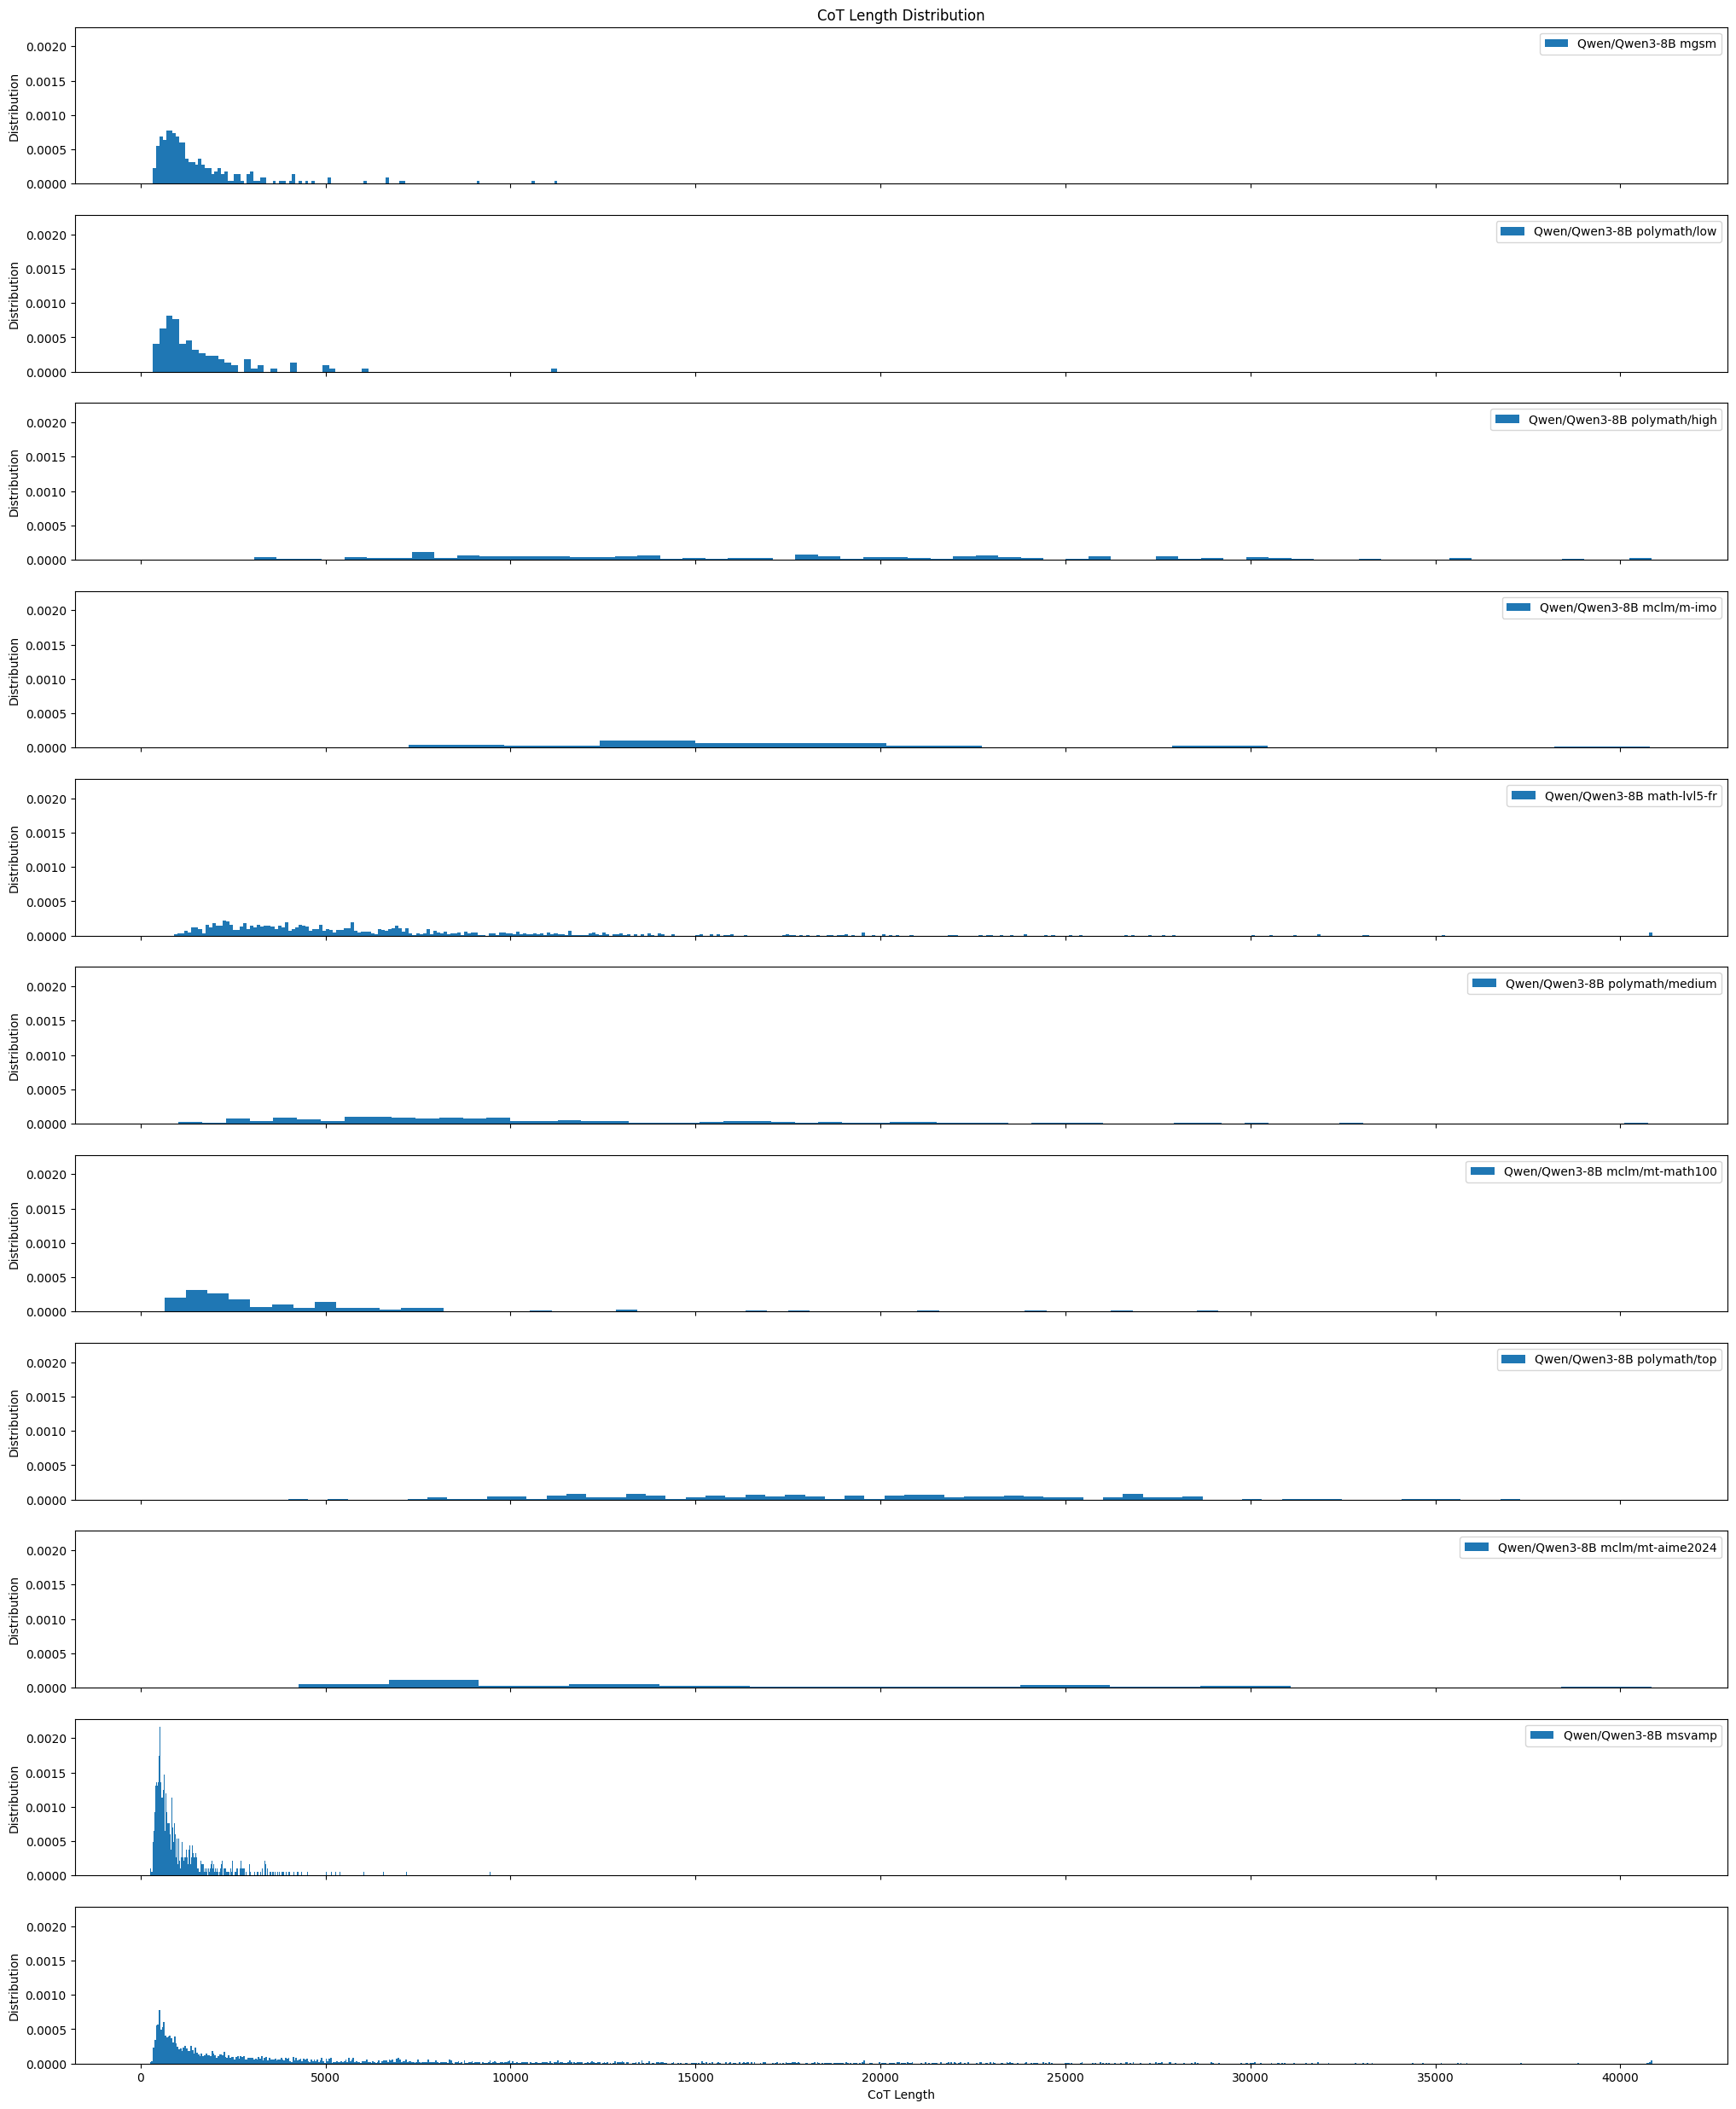

In [47]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True, sharey=True)
    axs[0].set_title("CoT Length Distribution")
    cot_lengths = []
    for i, dataset in enumerate(datasets):
        cot_lengths_dataset = []
        for sample in result["samples"][dataset]:
            cot_lengths_dataset.append(sample["cot_length"])
        cot_lengths += cot_lengths_dataset
        axs[i].hist(cot_lengths_dataset, label=model+" "+dataset, bins=len(cot_lengths_dataset)//2, density=True)
        axs[i].set_ylabel("Distribution")
        axs[i].legend()
    axs[-1].hist(cot_lengths, label=model+"average", bins=1000, density=True)
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Distribution")
    axs[-1].legend
    plt.savefig("cot_length")
    plt.show()

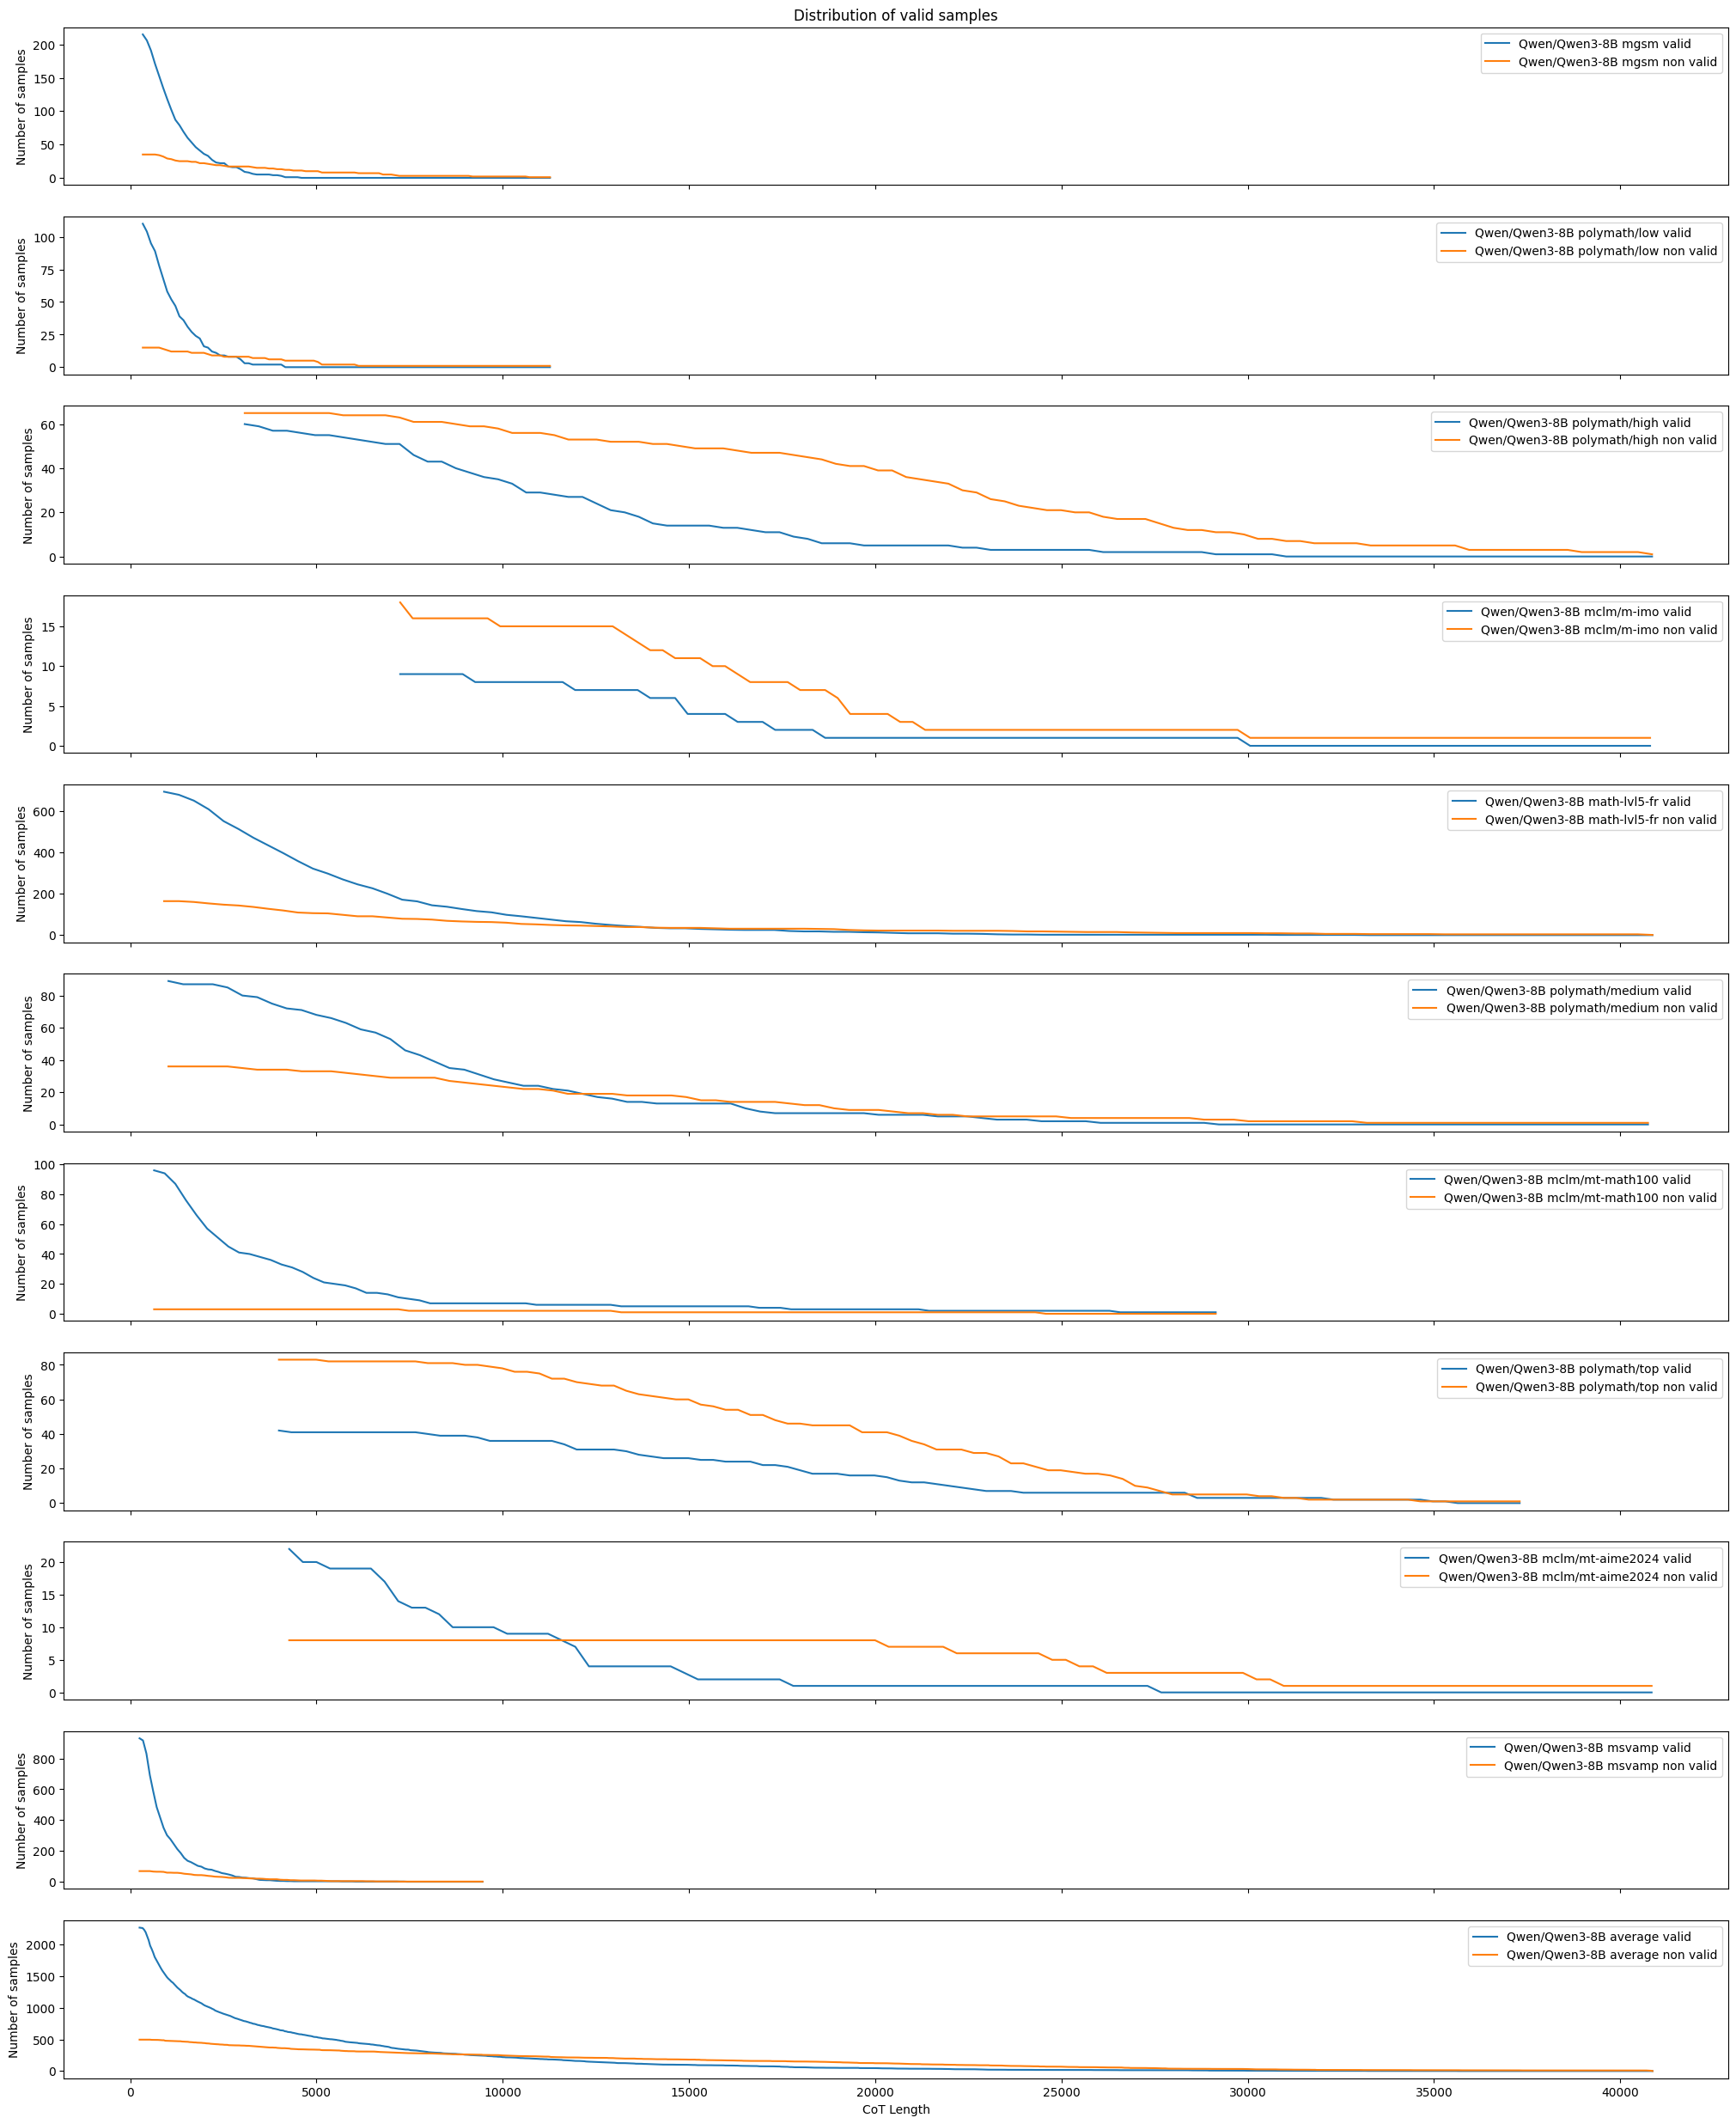

In [48]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True)
    axs[0].set_title("Distribution of valid samples")
    for i, dataset in enumerate(datasets):
        valid = []
        non_valid = []
        bins = np.histogram(
            [x["cot_length"] for x in result["samples"][dataset]],
            bins=100
        )[1]
        for x1, x2 in zip(bins, bins + [100000]):
            subset = [x["is_valid"] for x in result["samples"][dataset] if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
            total.append(len(subset))
            valid.append(sum(subset))
            non_valid.append(len(subset)-sum(subset))
        axs[i].plot(bins, valid, label=model+" "+dataset+" valid")
        axs[i].plot(bins, non_valid, label=model+" "+dataset+" non valid")
        axs[i].set_ylabel("Number of samples")
        axs[i].legend()
        
    bins = np.histogram(
        [x["cot_length"] for dataset_result in result["samples"].values() for x in dataset_result],
        bins=1000
    )[1]
    valid = []
    non_valid = []
    for x1, x2 in zip(bins, bins + [500000]):
        subset = [x["is_valid"] for dataset_result in result["samples"].values() for x in dataset_result if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
        valid.append(sum(subset))
        non_valid.append(len(subset)-sum(subset))
    axs[-1].plot(bins, valid, label=model+" average valid")
    axs[-1].plot(bins, non_valid, label=model+" average non valid")
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Number of samples")
    axs[-1].legend()
    plt.savefig("valid.png")
    plt.show()
    